In [1]:
import matrix
import numpy as np
import matplotlib.pyplot as plt
import base

# Christofides algorithm
### based on https://www.szi.uni-bremen.de/wp-content/uploads/2021/12/thesis_hafer.pdf and https://de.wikipedia.org/wiki/Algorithmus_von_Prim

* Create minimum spanning tree $T$
* Find a minimum-weight perfect matching $M$ for vertices with odd degrees of edges
* Form an Eulerian circuit in $T \cup M$
* Skip repeated vertices to form a hamiltonian circle

In [90]:
A,x,y =matrix.random_dist_matrix(30,0,2)
points = np.arange(len(A))

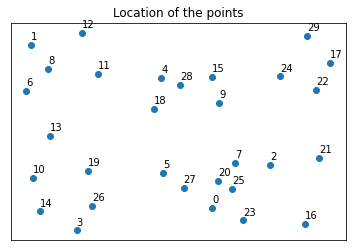

In [91]:
plt.scatter(x,y)
plt.title('Location of the points')
plt.xticks([])
plt.yticks([])
for i, txt in enumerate(points):
    plt.annotate(txt, (x[i], y[i]+0.05))
plt.show()

In [92]:
def prim(distance):
    """Calculate minimal spanning tree through prim algorihm:
       Always add edge to a new vertex with smallest value to existing tree
       Input: distance_ matrix containing distance to all the points
       Output: E_ edges connecting the tree in one array
               E_plot _  dges connecting the tree in matrix
       
    """
    Q = np.arange(len(distance)) # points
    V = np.array([]) # will contain vertices a,...
    E = [] # will contain edges (a,b)
    V = np.append(V,0)
    while len(V)!= len(Q): # Not all vertices used
        s = np.max(distance) # maximal value
        for k in range(len(V)): # look for every used vertex
            for i in range(len(Q)):
                if Q[i] not in V: # if new vertex is not used
                    if distance[int(V[k]),i] <= s: # find smallest distance
                        s = distance[int(V[k]),i]
                        j = i # memorize vertex position of new point
                        h = V[k] # memorize vertex from which new point is branching of
        V = np.append(V,j).astype(int)
        E = np.append(E,(h,j))
    E = np.reshape(E,(len(distance)-1,2)).astype(int)
    return E
                    

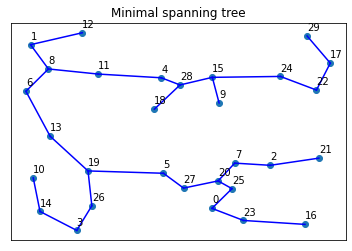

In [93]:
E= prim(A)
for z in range(len(E)):
    plt.plot(x[E[z]],y[E[z]],color ='blue')
plt.scatter(x,y)
plt.title('Minimal spanning tree')
plt.xticks([])
plt.yticks([])
for i, txt in enumerate(points):
    plt.annotate(txt, (x[i], y[i]+0.05))
plt.show()

In [94]:
def matching(tree,distances):
    """
    Search for vertices with odd number of edges. Matches these vertices with new edges with minimal distances.
    Input: tree_ minimal tree
           distances_ matrix conatining the distances
    Output: E_ minimal tree + matching edges -> result can create hamilton circle
    """
    M = np.array([])
    E = tree.flatten() #transform Matrix to 1d-array
    Count = np.zeros(len(distances)) 
    for z in range(len(distances)):# Count number of edges connected to a point
        for j in range(len(E)):
            if z == E[j]:
                Count[z]+=1
    Count = Count%2 # Check if number is even or odd
    for q in range(len(Count)):
        if Count[q]==1:
            M = np.append(M,q)# Odd vertices have to be matched
    while len(M)>0:# Match each vertex in M to another vertex in M via cheapest edge
        s = np.max(distances)
        for k in range(len(M)):
            for i in range(len(M)):
                if i != k:
                    if distances[int(M[k]),int(M[i])] <= s:
                        s = distances[int(M[k]),int(M[i])]
                        j = int(M[i])
                        h = int(M[k])
        # Add new edge to T and remove from the ones to be matched                
        E = np.append(E,(j,h))
        M = np.delete(M,np.where((M == j)))
        M = np.delete(M,np.where((M == h)))

    E = np.reshape(E,(len(E)//2,2)).astype(int)
    return E

In [95]:
E2 = matching(E,A)

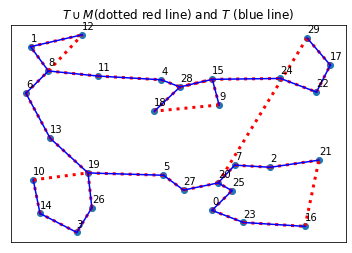

In [96]:
for z in range(len(E2)):
    plt.plot(x[E2[z]],y[E2[z]],color ='red',linewidth=3,  linestyle =':')
for z in range(len(E)):
    plt.plot(x[E[z]],y[E[z]],color ='blue')
plt.scatter(x,y)
plt.xticks([])
plt.yticks([])
plt.title('$T \cup M$(dotted red line) and $T$ (blue line)')
for i, txt in enumerate(points):
    plt.annotate(txt, (x[i], y[i]+0.05))
plt.show()

In [97]:
def euler_circle(tree,start =0):
    """
    euler_cirlce creates an eulerpath given an euler-tree
    Input: tree - tree of edges [a,b], which contains an euler path
            start - start point - default is 0
    Output: euler-tree
    
    """
    E = np.copy(tree)
    Trail =np.array([]) # will get euler-circle
    for q in range(len(E)):
        if tree[q,0] ==start: # search starting edge
            break
    Trail = np.append(Trail,E[q])
    E = np.delete(E,q,0) # remove this edge from avalable edges
    while len(E)>0:
        if Trail[0]!= Trail[-1]: # We do not have a circle
            k = len(E)+1 # Have we found the next edge?
            for q in range(len(E)): # We have abbc -> Look for edge [c,d]
                if E[q,0] == Trail[-1]:
                    k = q
                    break  
            if k < len(E):
                Trail = np.append(Trail,E[k])
                E = np.delete(E,k,0)
            else:
                for q in range(len(E)):# We have abbc -> Look for edge [d,c] and invert it
                    if E[q,1] == Trail[-1]:
                        k = q
                        break  
                if k < len(E):
                    Trail = np.append(Trail,np.flip(E[k]))
                    E = np.delete(E,k,0)
        else: # We do have a circle
            for q in range(len(E)): 
                if E[q,0] in Trail: # We have edge [d,f] search for vertex d in trail
                    circle = np.where(Trail == q)
                    d = circle[0][0]
                    Taril =np.roll(Trail,d)
                    Trail = np.append(Trail,E[q])
                    
                    E = np.delete(E,q,0)
                    break
                if E[q,1] in Trail:
                    circle = np.where(Trail == q)
                    d = circle[0][0]
                    Taril =np.roll(Trail,d)
                    Trail = np.append(Trail,np.flip(E[q]))
                    
                    E = np.delete(E,q,0)
                    break
    Trail = np.reshape(Trail,(len(Trail)//2,2)).astype(int)         
    return Trail
        

In [98]:
Trail =euler_circle(E2)

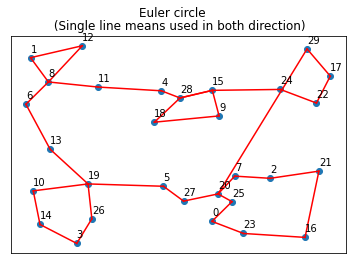

In [99]:
for z in range(len(Trail)):
    plt.plot(x[Trail[z]],y[Trail[z]],color ='red')
plt.scatter(x,y)
plt.xticks([])
plt.yticks([])
plt.title(' (Single line means used in both direction)')
plt.suptitle('Euler circle')
for i, txt in enumerate(points):
    plt.annotate(txt, (x[i], y[i]+0.05))
plt.show()

In [100]:
def hamilton(euler_tree):
    """
    Input: Eulerian circuit_ Matrix of edges
    Output: Hamiltonian circuit_ 1d-array
    
    """
    euler = euler_tree.flatten()
    hamilton = np.array([])
    for x in range(len(euler)):
        if euler[x] not in hamilton: # Only add new numbers to hamilton circle
            hamilton = np.append(hamilton,euler[x]).astype(int)
    hamilton = np.append(hamilton,hamilton[0]) # add first vertex to get a closed circuit
    return hamilton

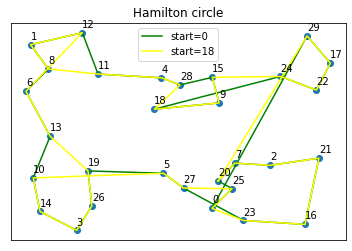

In [103]:

hamilt =hamilton(Trail)
hamilt18 = hamilton(euler_circle(E2,start =18))
plt.plot(x[hamilt],y[hamilt],color ='green', label ='start=0')
plt.plot(x[hamilt18],y[hamilt18],color ='yellow', label ='start=18')
plt.scatter(x,y)
plt.xticks([])
plt.yticks([])
plt.title('Hamilton circle')
plt.legend()
for i, txt in enumerate(points):
    plt.annotate(txt, (x[i], y[i]+0.05))
plt.show()

In [80]:
def christofides(distances,start=0):
    """
    Input: distances_ Matrix conatining distances between points
           start_Startpoint of sequence_default=0
    Output: solution of tsp with Christofides algorithm
    """
    min_tree = prim(distances)
    match = matching(min_tree,distances)
    euler = euler_circle(match,start)
    return hamilton(euler)

In [81]:
christ = christofides(A)


# Comparison Christofides/Monte-Carlo

In [83]:
points = np.arange(len(A))
monte,dist,temp = base.traveling_MC_constDist(points,A,10000)


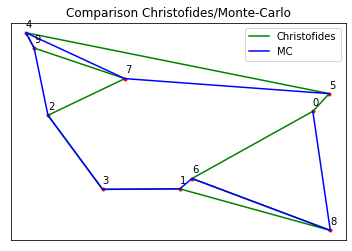

In [86]:
plt.plot(x[christ],y[christ], color = 'green',label = 'Christofides')
plt.plot(x[monte],y[monte], color = 'blue', label = 'MC')
plt.scatter(x,y,marker ='.',color = 'red')
plt.xticks([])
plt.yticks([])
plt.title('Comparison Christofides/Monte-Carlo')
for i, txt in enumerate(points):
    plt.annotate(txt, (x[i], y[i]+0.05))
plt.legend()
plt.show()

Mir ist aufgefallen, dass sich unser MC nicht schließt. Daher habe ich folgende Änderungen eingeführt.

In [22]:
def traveling_MC_constDist(points, dist_matrix, tries, starting_temp = 1, alpha = 0.999, method =2):
    """ input:  points - points that should be visited by each path (in some order) - array
                dist_matrix - matrix containing the 'distances' between each point - 2darray
                tries - itterations of the Monte Carlos - Markov chain - int
                starting_temp - scalar in the exponent of the markov chain acception process - int
                alpha - scalar refgulating the decrease of the temperature after each loop iteration in the MC
                method - see Opt_method- cuurently random between Lin-2 & Lin-3
        return: points - points that should be visited by each path (in some order) - array
                pathWeights - 'distances' (better weights) of each path - array of int
                temps - temperatures after each MC step - array of int
    """
    points = np.append(points,points[0]) #Schließe die Punkte zu einem Kreis   #Neu
    pathWeights = np.zeros(tries+1)
    temps = np.zeros(tries+1)
    pathWeights[0] = base.totalTravelDist(points, dist_matrix)
    temps[0] = starting_temp
    cost = pathWeights[0]
    
    for i in range(tries):
        points = np.delete(points,-1)#Entferne Kreispunkt               #NEU
        new_sequence = base.Opt_method(method,points)
        new_sequence = np.append(new_sequence,new_sequence[0])#Schließe die Punkte zu einem Kreis #NEU 
        new_cost = base.totalTravelDist(new_sequence, dist_matrix)
        if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
            points = new_sequence
            cost = new_cost
        else:                                                           #NEU
            points = np.append(points,points[0])#Schließe die Punkte zu einem Kreis     #NEU
        pathWeights[i+1] = cost
        temps[i+1] = alpha*temps[i] 
    return(points, pathWeights, temps)

In [87]:
monte_loop,dist_2,temp = traveling_MC_constDist(points,A,10000)

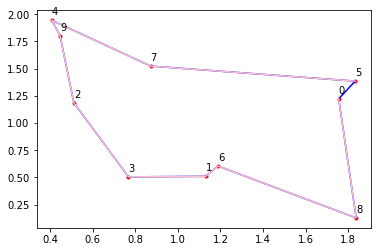

In [88]:

plt.plot(x[monte_loop],y[monte_loop], color = 'blue',label = 'MC_loop')
plt.plot(x[monte],y[monte], color = 'pink', label = 'MC_open')
for i, txt in enumerate(points):
    plt.annotate(txt, (x[i], y[i]+0.05))
plt.scatter(x,y,marker ='.',color = 'red')
plt.show()

Christofides führt ebenfalls nicht zum Minimum. Außerdem ist es abhängig von der Startposition vom Hamiltonkreis.

In [89]:
print('Christofides',base.totalTravelDist(christ,A))
print('Dist_old',dist[-1])
print('Dist_loop',dist_2[-1])

Christofides 6.393770022335271
Dist_old 5.645506752574926
Dist_loop 5.645506752574927
